In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, make_scorer

df_train =  pd.read_csv("aerosols-img/train.csv")
print(df_train.head())
print(df_train.describe())
print(df_train.info())

   id  elevation  ozone    NO2  azimuth  zenith  incidence_azimuth  \
0   1         10    318  0.248    150.6    31.8              286.1   
1   2         10    302  0.279    161.6    44.2              243.6   
2   4         10    373  0.303    163.5    34.4              103.9   
3   5         10    342  0.271    144.7    25.3              286.2   
4   6         10    327  0.252    140.4    29.4              105.8   

   incidence_zenith                                       file_name_l1  \
0               8.0  AAOT_45-3139_12-5083_COPERNICUS_S2_20180807T10...   
1               3.9  AAOT_45-3139_12-5083_COPERNICUS_S2_20180916T10...   
2               9.8  AAOT_45-3139_12-5083_COPERNICUS_S2_20190421T10...   
3               7.9  AAOT_45-3139_12-5083_COPERNICUS_S2_20190623T10...   
4               7.0  AAOT_45-3139_12-5083_COPERNICUS_S2_20190720T10...   

   value_550  
0      0.277  
1      0.201  
2      0.169  
3      0.107  
4      0.188  
                 id     elevation         oz

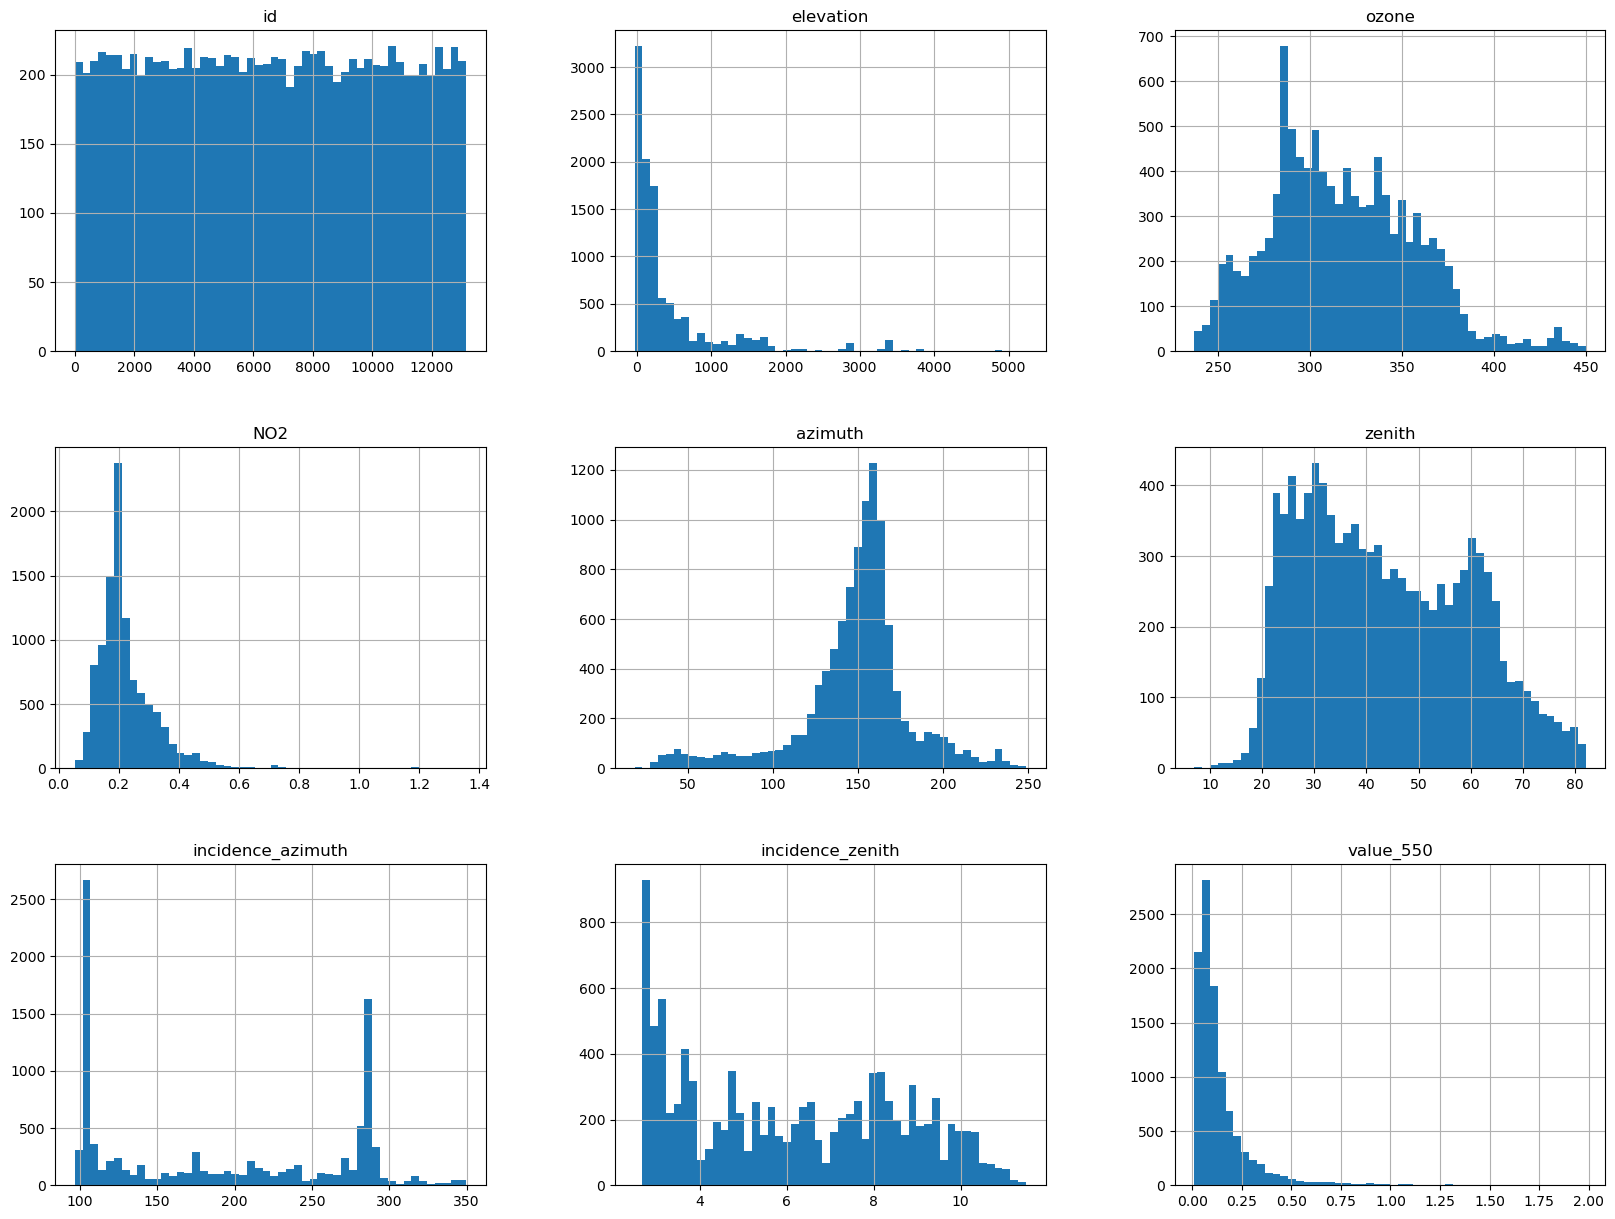

In [68]:
df_train.hist(bins=50, figsize=(20,15))
plt.show()

In [69]:
X = df_train.drop(columns=['file_name_l1','value_550'])
y = df_train['value_550']

assert isinstance(X, pd.DataFrame)
assert isinstance(y, pd.Series)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=10)

scaler =  StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout, BatchNormalization
from keras.regularizers import l2
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras.models import Sequential

In [92]:
def create_model(optimizer='adam',
                kernel_regularizer_1=0.0001,
                kernel_regularizer_2=0.001,
                kernel_regularizer_3=0.01,
                dropout_rate_1=0.7,
                dropout_rate_2=0.5,
                dropout_rate_3=0.2):
    model= Sequential([
        Dense(1280,activation='relu',kernel_regularizer=l2(kernel_regularizer_1)),
        BatchNormalization(),
        Dropout(dropout_rate_1),
        Dense(640, activation='relu',kernel_regularizer=l2(kernel_regularizer_2)),
        BatchNormalization(),
        Dropout(dropout_rate_2),
        Dense(320, activation='relu',kernel_regularizer=l2(kernel_regularizer_3)),
        BatchNormalization(),
        Dropout(dropout_rate_3),
        Dense(1)
    ])
    model.compile(optimizer=optimizer, loss= 'mean_squared_error',metrics=['MeanSquaredError','AUC'])
    return model

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

model = KerasRegressor(build_fn=create_model, epochs=300, batch_size=32, verbose=0)

param_grid = {
    'model_optimizer': ['adam', 'rmsprop', 'sgd'],
    'model_kernel_regularizer': [None, l2(0.0001), l2(0.001), l2(0.01)],
    'model_dropout_rate': [0.0, 0.1, 0.2, 0.3],
    'model_epochs': [100, 200, 300],
    'model_hidden_layers': [1, 2, 3],
    'model_units_per_layer': [256, 512, 1024],
    'model_learning_rate': [0.001, 0.01, 0.1]
}


pred = model.predict(X_test)


Fitting 3 folds for each of 3888 candidates, totalling 11664 fits


/tmp/ipykernel_18160/618563811.py:26: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model = KerasRegressor(build_fn=create_model, epochs=300, batch_size=32, verbose=0)


ValueError: model_dropout_rate is not a legal parameter